# Histogram task untied exp

In [1]:
import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt
import torch
import glob
import os

In [2]:
run_id = "20251201_1537" # ok top pour le rapport 
# run_id = "20251208_0815" # attention matrix

run_dir = f"../results/run_{run_id}/"
config_path = f"../results/run_{run_id}/config.csv"
base_path = f"../results/run_{run_id}/summary.csv"

plot_path = f"../results/run_{run_id}/plots/"
os.makedirs(plot_path, exist_ok=True)

## 1. experiment config

In [3]:
# --- Read the CSV file ---
config = pd.read_csv(config_path)
print(f"⚙️ Config loaded ({len(config)} rows) from {config_path}")

# --- Quick preview ---
display(config)

⚙️ Config loaded (15 rows) from ../results/run_20251201_1537/config.csv


,D,L,T,d_mlp_list,alpha,rho,beta,lambda,samples,max_iter,...,p_fine_tune,device,logger,run_dir,run_index,seed,batch_size,R,N,MLP_dim
0,100,15,30,"[5, 10, 30, 50]",0.100000,1.0,1.0,0.0001,20,5000,...,0.15,cuda,<Logger logger_0_2738908 (DEBUG)>,/home/peucelle/tpiv-simulations/results/run_20...,0,42,64,100,10,50
1,100,15,30,"[5, 10, 30, 50]",0.807143,1.0,1.0,0.0001,20,5000,...,0.15,cuda,<Logger logger_1_2738909 (DEBUG)>,/home/peucelle/tpiv-simulations/results/run_20...,1,42,64,100,80,50
2,100,15,30,"[5, 10, 30, 50]",1.514286,1.0,1.0,0.0001,20,5000,...,0.15,cuda,<Logger logger_2_2738910 (DEBUG)>,/home/peucelle/tpiv-simulations/results/run_20...,2,42,64,100,151,50
3,100,15,30,"[5, 10, 30, 50]",2.221429,1.0,1.0,0.0001,20,5000,...,0.15,cuda,<Logger logger_3_2738911 (DEBUG)>,/home/peucelle/tpiv-simulations/results/run_20...,3,42,64,100,222,50
4,100,15,30,"[5, 10, 30, 50]",3.635714,1.0,1.0,0.0001,20,5000,...,0.15,cuda,<Logger logger_5_2738913 (DEBUG)>,/home/peucelle/tpiv-simulations/results/run_20...,5,42,64,100,363,50
5,100,15,30,"[5, 10, 30, 50]",2.928571,1.0,1.0,0.0001,20,5000,...,0.15,cuda,<Logger logger_4_2738912 (DEBUG)>,/home/peucelle/tpiv-simulations/results/run_20...,4,42,64,100,292,50
6,100,15,30,"[5, 10, 30, 50]",5.050000,1.0,1.0,0.0001,20,5000,...,0.15,cuda,<Logger logger_7_2738915 (DEBUG)>,/home/peucelle/tpiv-simulations/results/run_20...,7,42,64,100,505,50
7,100,15,30,"[5, 10, 30, 50]",4.342857,1.0,1.0,0.0001,20,5000,...,0.15,cuda,<Logger logger_6_2738914 (DEBUG)>,/home/peucelle/tpiv-simulations/results/run_20...,6,42,64,100,434,50
8,100,15,30,"[5, 10, 30, 50]",7.878571,1.0,1.0,0.0001,20,5000,...,0.15,cuda,<Logger logger_11_2738919 (DEBUG)>,/home/peucelle/tpiv-simulations/results/run_20...,11,42,64,100,787,50
9,100,15,30,"[5, 10, 30, 50]",5.757143,1.0,1.0,0.0001,20,5000,...,0.15,cuda,<Logger logger_8_2738916 (DEBUG)>,/home/peucelle/tpiv-simulations/results/run_20...,8,42,64,100,575,50


## 2. Metric as function of $\alpha$ for different $\rho$

✅ Summary loaded (60 rows) from ../results/run_20251201_1537/summary.csv


<>:160: SyntaxWarning: invalid escape sequence '\k'
<>:187: SyntaxWarning: invalid escape sequence '\k'
<>:216: SyntaxWarning: invalid escape sequence '\D'
<>:160: SyntaxWarning: invalid escape sequence '\k'
<>:187: SyntaxWarning: invalid escape sequence '\k'
<>:216: SyntaxWarning: invalid escape sequence '\D'
/var/folders/ml/mckm5tb169sckcm9zfghvmm80000gn/T/ipykernel_89916/1219828327.py:160: SyntaxWarning: invalid escape sequence '\k'
  plt.ylabel("$\kappa_0$ (before fine-tune)")
/var/folders/ml/mckm5tb169sckcm9zfghvmm80000gn/T/ipykernel_89916/1219828327.py:187: SyntaxWarning: invalid escape sequence '\k'
  plt.ylabel("$\kappa_0$ (after fine-tune)")
/var/folders/ml/mckm5tb169sckcm9zfghvmm80000gn/T/ipykernel_89916/1219828327.py:216: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel("$\Delta \kappa_0$")


,alpha,MLP_dim,rho,label_err_mean,label_err_std,train_data_mean,train_reg_mean,train_total_mean,train_total_std,acc_test_mean,acc_test_std,acc_fine_tune_mean,acc_fine_tune_std,acc_train_mean,acc_train_std,rank_before_mean,rank_before_std,rank_after_mean,rank_after_std
0,0.100000,5,1.0,0.000096,0.000002,2.745174e-06,0.000013,0.000016,6.407575e-06,0.040000,0.024423,1.000000,0.000000,0.989829,0.018812,99.80,0.410391,99.50,0.888523
1,0.100000,10,1.0,0.000083,0.000002,1.147868e-06,0.000011,0.000013,2.792606e-06,0.170833,0.020142,1.000000,0.000000,0.998871,0.003916,99.55,0.759155,99.70,0.571241
2,0.100000,30,1.0,0.000088,0.000008,7.968677e-07,0.000011,0.000012,1.260433e-06,0.122500,0.082412,0.955733,0.074443,1.000000,0.000000,99.65,0.489360,99.20,0.523148
3,0.100000,50,1.0,0.000097,0.000003,5.808530e-07,0.000008,0.000009,3.813734e-07,0.030833,0.034317,0.035413,0.065155,1.000000,0.000000,99.10,0.552506,98.60,1.142481
4,0.807143,5,1.0,0.000069,0.000005,1.417255e-04,0.000019,0.000160,1.682212e-05,0.313889,0.045963,0.380205,0.045795,0.486110,0.072910,100.00,0.000000,99.65,0.489360


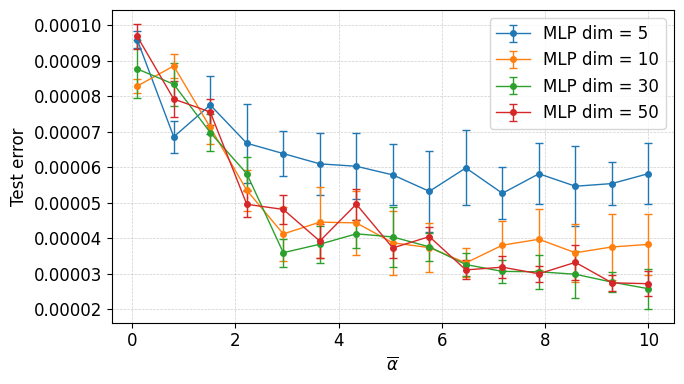

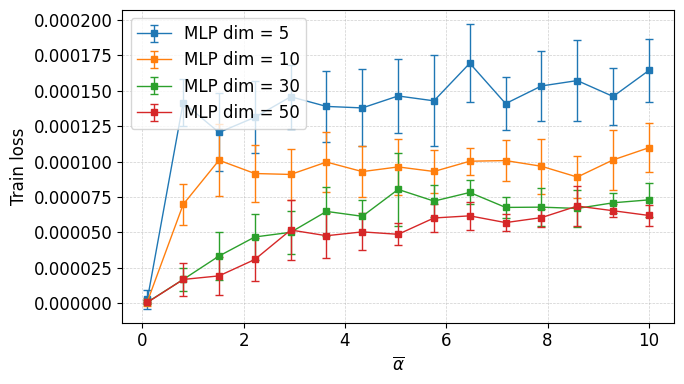

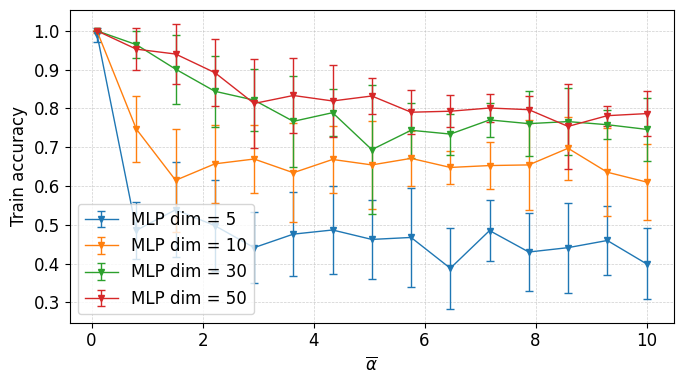

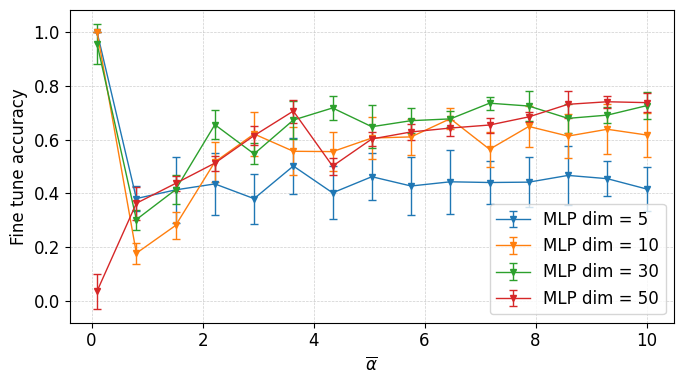

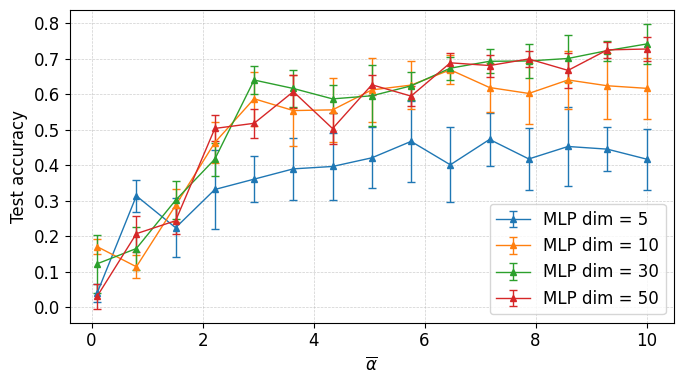

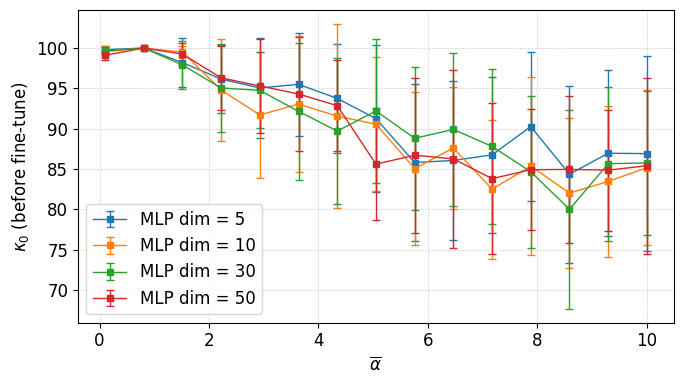

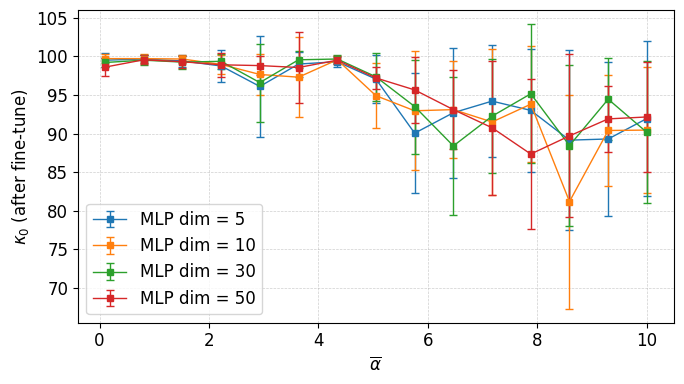

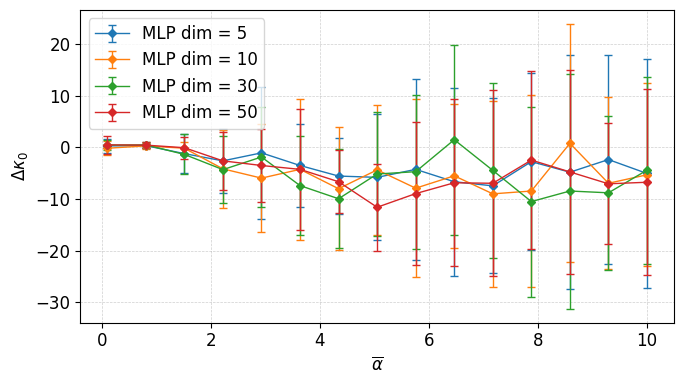

In [4]:
# --- Read the CSV file ---
df = pd.read_csv(base_path)
print(f"✅ Summary loaded ({len(df)} rows) from {base_path}")

# --- Quick preview ---
display(df.head())

plt.rcParams.update({'font.size': 12}) 

# --- Plot Label Error vs alpha with error bars (grouped by MLP_dim) ---
plt.figure(figsize=(7, 4))
for MLP_dim in sorted(df["MLP_dim"].unique()):
    subset = df[df["MLP_dim"] == MLP_dim].sort_values("alpha")
    plt.errorbar(
        subset["alpha"],
        subset["label_err_mean"],
        yerr=subset.get("label_err_std", 0),
        marker='o',
        markersize=4,
        linewidth=1,
        capsize=3,
        label=f"MLP dim = {MLP_dim}"
    )
plt.xlabel(r"$\overline{\alpha}$")
plt.ylabel("Test error")
# plt.title(f"Label Error vs α")
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig(
    os.path.join(plot_path, f"label_error_vs_alpha_run{run_id}.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# --- Plot Train Data vs alpha with error bars (grouped by MLP_dim) ---
plt.figure(figsize=(7, 4))
for MLP_dim in sorted(df["MLP_dim"].unique()):
    subset = df[df["MLP_dim"] == MLP_dim].sort_values("alpha")
    plt.errorbar(
        subset["alpha"],
        subset["train_data_mean"],
        yerr=subset.get("train_total_std", 0),
        marker='s',           
        markersize=4,
        linewidth=1,
        capsize=3,
        label=f"MLP dim = {MLP_dim}"
    )
plt.xlabel(r"$\overline{\alpha}$")
plt.ylabel("Train loss")
# plt.title(f"Train Data vs α")
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig(
    os.path.join(plot_path, f"train_data_vs_alpha_run{run_id}.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# --- Plot Train Data vs alpha with error bars (grouped by lambda) ---
plt.figure(figsize=(7, 4))
for MLP_dim in sorted(df["MLP_dim"].unique()):
    subset = df[df["MLP_dim"] == MLP_dim].sort_values("alpha")
    plt.errorbar(
        subset["alpha"],
        subset["acc_train_mean"],
        yerr=subset.get("acc_train_std", 0),
        marker='v',          # downward triangle to differ from test accuracy (^)
        markersize=4,
        linewidth=1,
        capsize=3,
        label=f"MLP dim = {MLP_dim}"
    )
plt.xlabel(r"$\overline{\alpha}$")
plt.ylabel("Train accuracy")
# plt.title(f"Train Accuracy vs α")
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig(
    os.path.join(plot_path, f"train_accuracy_vs_alpha_run{run_id}.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# --- Plot Train Data vs alpha with error bars (grouped by lambda) ---
plt.figure(figsize=(7, 4))
for MLP_dim in sorted(df["MLP_dim"].unique()):
    subset = df[df["MLP_dim"] == MLP_dim].sort_values("alpha")
    plt.errorbar(
        subset["alpha"],
        subset["acc_fine_tune_mean"],
        yerr=subset.get("acc_fine_tune_std", 0),
        marker='v',          # downward triangle to differ from test accuracy (^)
        markersize=4,
        linewidth=1,
        capsize=3,
        label=f"MLP dim = {MLP_dim}"
    )
plt.xlabel(r"$\overline{\alpha}$")
plt.ylabel("Fine tune accuracy")
# plt.title(f"Fine Tune Accuracy vs α")
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig(
    os.path.join(plot_path, f"fine_tune_accuracy_vs_alpha_run{run_id}.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# --- Plot Train Data vs alpha with error bars (grouped by lambda) ---
plt.figure(figsize=(7, 4))
for MLP_dim in sorted(df["MLP_dim"].unique()):
    subset = df[df["MLP_dim"] == MLP_dim].sort_values("alpha")
    plt.errorbar(
        subset["alpha"],
        subset["acc_test_mean"],
        yerr=subset.get("acc_test_std", 0),
        marker='^',
        markersize=4,
        linewidth=1,
        capsize=3,
        label=f"MLP dim = {MLP_dim}"
    )
plt.xlabel(r"$\overline{\alpha}$")
plt.ylabel("Test accuracy")
# plt.title(f"Test Accuracy vs α")
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig(
    os.path.join(plot_path, f"test_accuracy_vs_alpha_run{run_id}.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# --- rank before fine tune---
plt.figure(figsize=(7, 4))
for MLP_dim in sorted(df["MLP_dim"].unique()):
    subset = df[df["MLP_dim"] == MLP_dim].sort_values("alpha")
    plt.errorbar(
        subset["alpha"],
        subset["rank_before_mean"],
        yerr=subset.get("rank_before_std", 0),
        marker='s',          # carré = clair, académique, lisible
        markersize=4,
        linewidth=1,
        capsize=3,
        label=f"MLP dim = {MLP_dim}"
    )
plt.xlabel(r"$\overline{\alpha}$")
plt.ylabel("$\kappa_0$ (before fine-tune)")
# plt.title("Rank of $W_0$ (before fine-tune)")
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig(
    os.path.join(plot_path, f"rank_before_vs_alpha_run{run_id}.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# --- rank after fine tune ---
plt.figure(figsize=(7, 4))
for MLP_dim in sorted(df["MLP_dim"].unique()):
    subset = df[df["MLP_dim"] == MLP_dim].sort_values("alpha")
    plt.errorbar(
        subset["alpha"],
        subset["rank_after_mean"],
        yerr=subset.get("rank_after_std", 0),
        marker='s',          # carré pour cohérence avec rank_before
        markersize=4,
        linewidth=1,
        capsize=3,
        label=f"MLP dim = {MLP_dim}"
    )
plt.xlabel(r"$\overline{\alpha}$")
plt.ylabel("$\kappa_0$ (after fine-tune)")
# plt.title("Rank of $W_0$ (after fine-tune)")
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig(
    os.path.join(plot_path, f"rank_after_vs_alpha_run{run_id}.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# --- diff rank ---
plt.figure(figsize=(7, 4))
for MLP_dim in sorted(df["MLP_dim"].unique()):
    subset = df[df["MLP_dim"] == MLP_dim].sort_values("alpha")
    diff_mean = subset["rank_before_mean"] - subset["rank_after_mean"]
    diff_std  = subset.get("rank_before_std", 0) + subset.get("rank_after_std", 0)
    plt.errorbar(
        subset["alpha"],
        diff_mean,
        yerr=diff_std,
        marker='D',         
        markersize=4,
        linewidth=1,
        capsize=3,
        label=f"MLP dim = {MLP_dim}"
    )
plt.xlabel(r"$\overline{\alpha}$")
plt.ylabel("$\Delta \kappa_0$")
# plt.title("Rank Difference of $W_0$ (before – after fine-tune)")
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig(
    os.path.join(plot_path, f"rank_diff_vs_alpha_run{run_id}.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## 3. Results visualisation

Found 2 heavy_data files.

--- File: ../results/run_20251208_0815/heavy_data_0.pkl ---
W_runs: type=list, length=100
  first element shape: (100, 100), dtype=float32
acc_train: type=list, length=100
  first element type: <class 'list'>


📊 Global mean of averaged eigenvalues = 4.675125


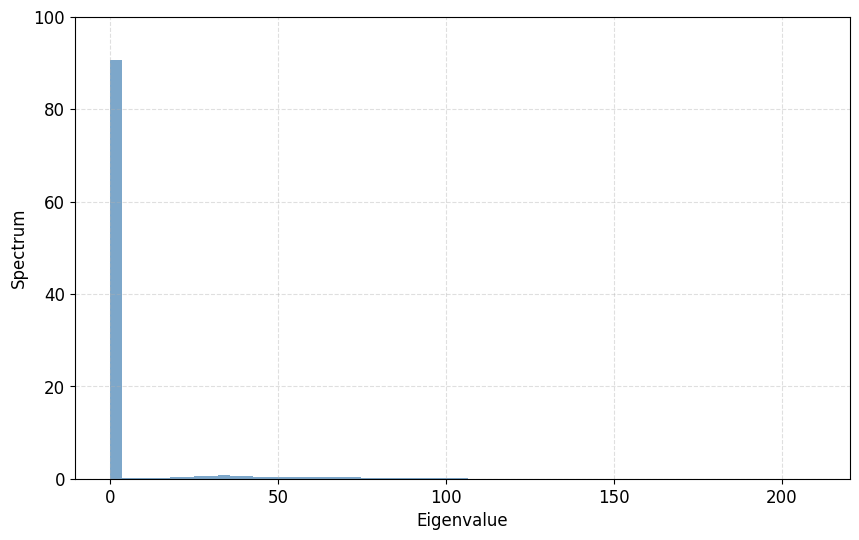

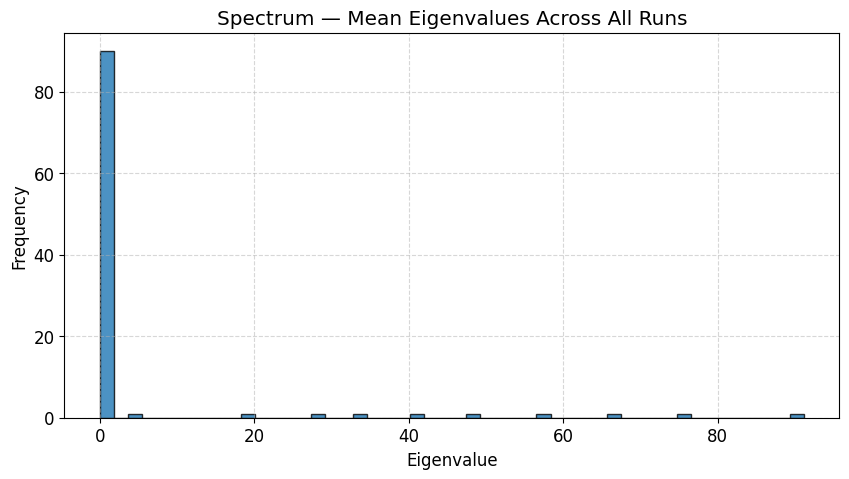

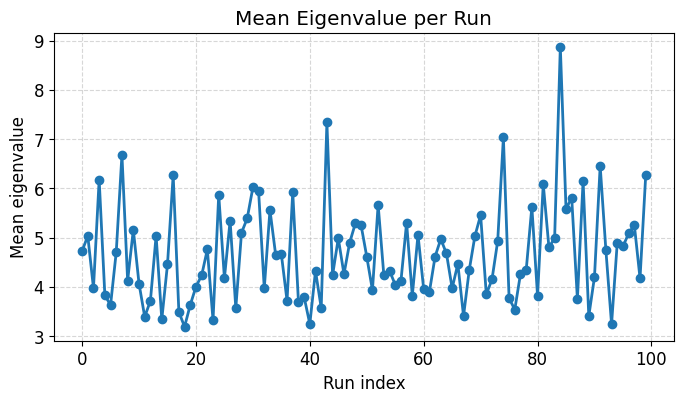

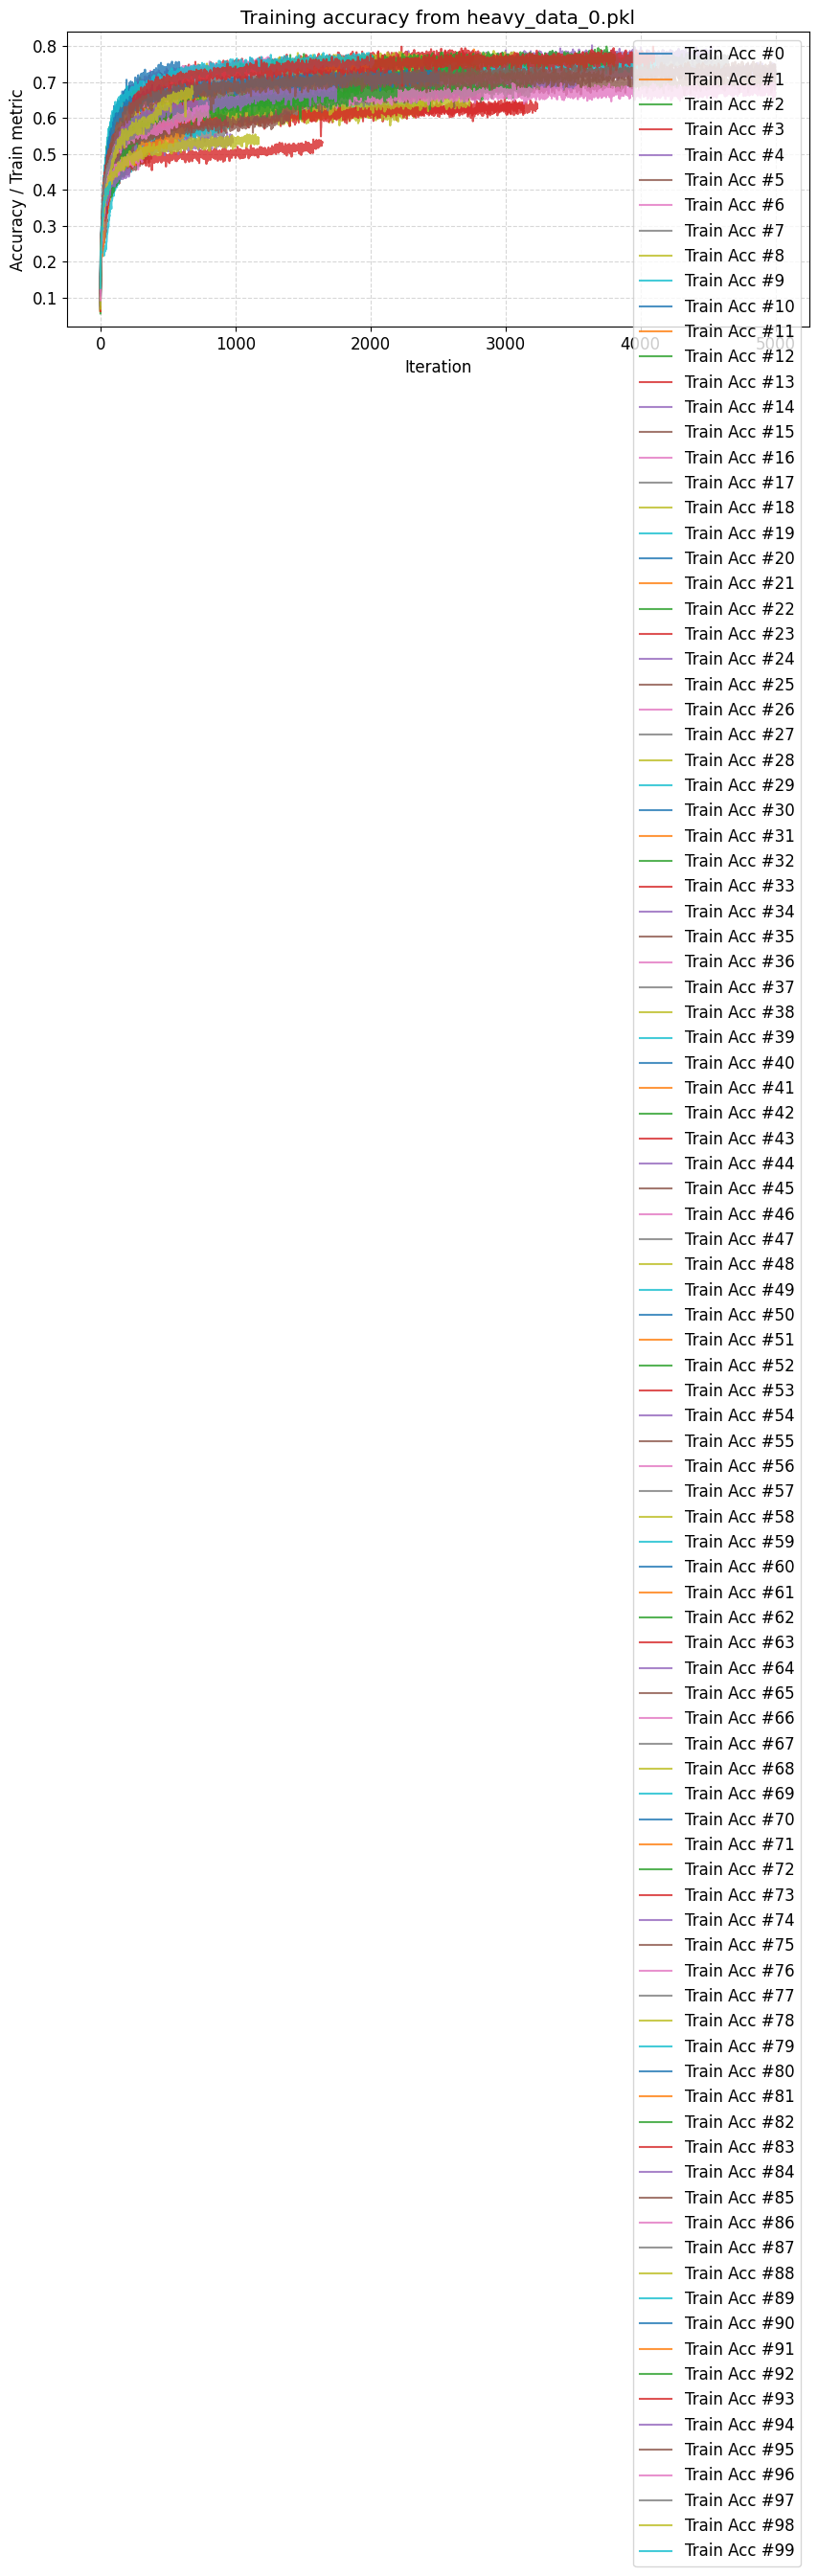

--- File: ../results/run_20251208_0815/heavy_data_1.pkl ---
W_runs: type=list, length=100
  first element shape: (100, 100), dtype=float32
acc_train: type=list, length=100
  first element type: <class 'list'>


📊 Global mean of averaged eigenvalues = 4.517868


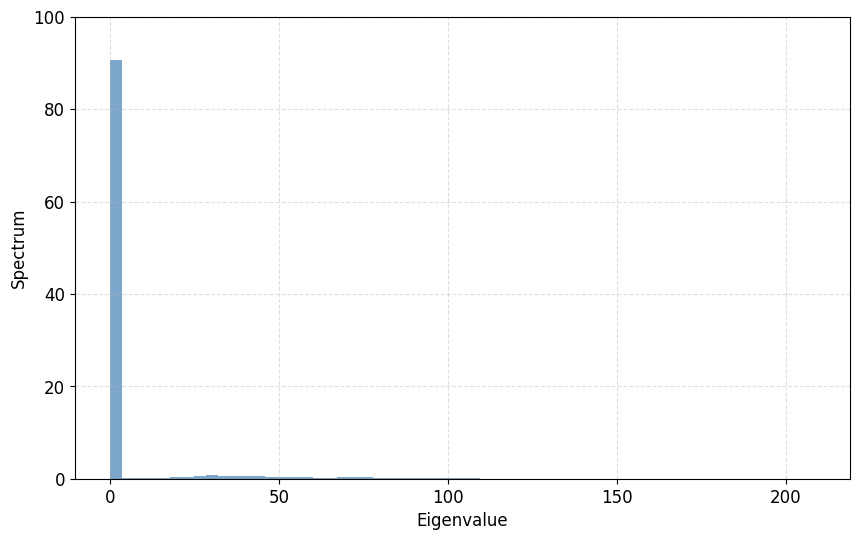

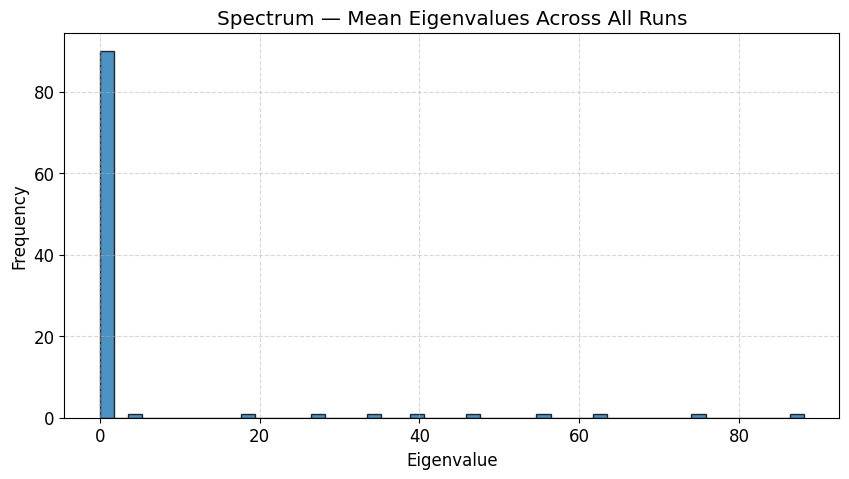

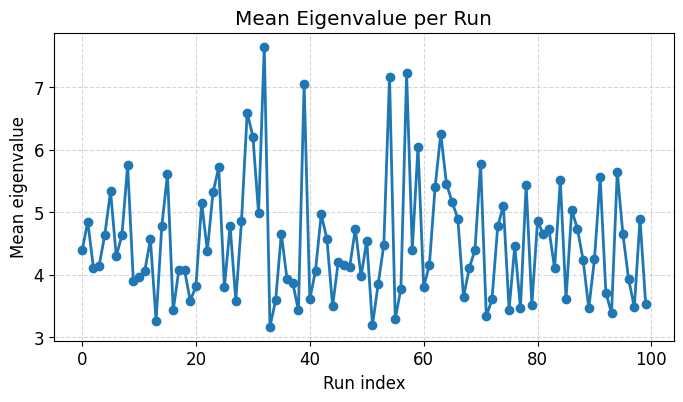

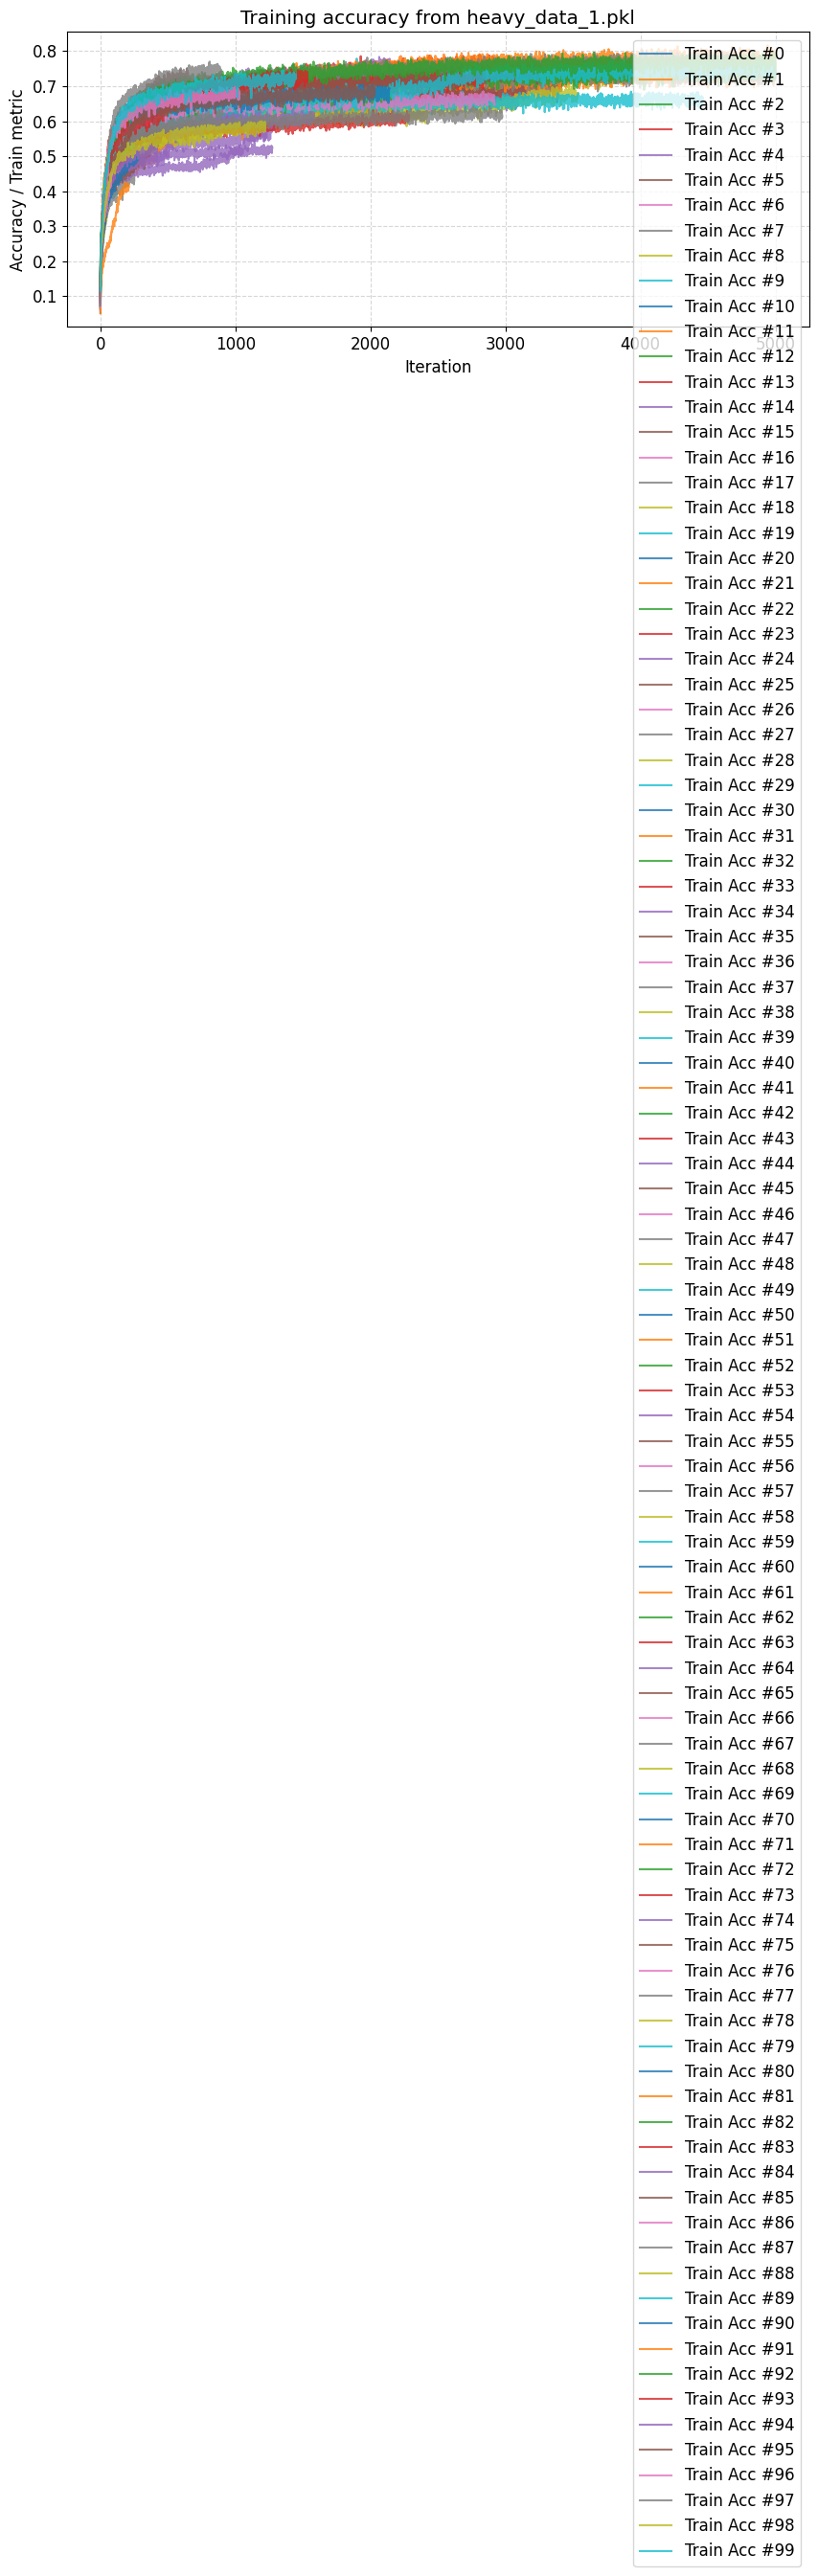

In [10]:
def highlight_diagonal(ax, seq_len, color='red', lw=2):
    """Draw rectangles along the diagonal of a matrix plot"""
    for i in range(seq_len):
        rect = plt.Rectangle((i-0.5, i-0.5), 1, 1, fill=False, color=color, lw=lw)
        ax.add_patch(rect)

def plot_heavy_data_with_metrics(run_dir, max_plots=5, overlay_y_samples=True, show_shapes=True):
    """
    Plot eigenvalue spectra, attention matrices, sequence samples, and acc_train from the heavy_data pickle.
    Only plots up to max_plots λ values per run.
    overlay_y_samples: if True, plots y_samples overlay on attention matrices.
    show_shapes: if True, prints all keys with type/shape info.
    """
    heavy_files = sorted(glob.glob(os.path.join(run_dir, "heavy_data_*.pkl")))
    print(f"Found {len(heavy_files)} heavy_data files.\n")

    for heavy_file in heavy_files:
        print(f"--- File: {heavy_file} ---")
        with open(heavy_file, "rb") as f:
            data = pickle.load(f)
        
        if show_shapes:
            # Afficher toutes les clés et shape/type
            for key, val in data.items():
                if isinstance(val, np.ndarray):
                    print(f"{key}: type={type(val)}, shape={val.shape}, dtype={val.dtype}")
                elif isinstance(val, torch.Tensor):
                    print(f"{key}: type={type(val)}, shape={val.shape}, dtype={val.dtype}")
                elif isinstance(val, list):
                    print(f"{key}: type=list, length={len(val)}")
                    if len(val) > 0:
                        first = val[0]
                        if isinstance(first, np.ndarray):
                            print(f"  first element shape: {first.shape}, dtype={first.dtype}")
                        elif isinstance(first, torch.Tensor):
                            print(f"  first element shape: {first.shape}, dtype={first.dtype}")
                        else:
                            print(f"  first element type: {type(first)}")
                else:
                    print(f"{key}: type={type(val)}")
            print("\n")

        W_runs_all = data.get("W_runs", [])
        attn_matrices = data.get("attn_matrices", [])
        seq_samples = data.get("seq_samples", [])
        y_samples = data.get("y_samples", None)
        acc_train = data.get("acc_train", None)

        # --- Plots Eigenvalue & Attention ---
        # --- Compute eigenvalue spectra for all W ---
        eigvals_runs = []

        for W in W_runs_all:
            eigvals = np.linalg.eigvalsh(W @ W.T)
            eigvals_runs.append(eigvals)

        # --- Pad or truncate to match lengths (if needed) ---
        min_len = min(len(ev) for ev in eigvals_runs)
        eigvals_runs = np.array([ev[:min_len] for ev in eigvals_runs])

        # --- Mean eigenvalues per run ---
        mean_per_run = eigvals_runs.mean(axis=1)

        # --- Global mean of means (as requested) ---
        global_mean_mean = mean_per_run.mean()

        print(f"📊 Global mean of averaged eigenvalues = {global_mean_mean:.6f}")

        plt.figure(figsize=(10, 6))

        # Déterminer les bins communs pour tous les runs
        all_eigvals = np.concatenate([np.linalg.eigvalsh(W @ W.T) for W in W_runs_all])
        bins = np.linspace(all_eigvals.min(), all_eigvals.max(), 60)

        # Cumuler les histogrammes
        cum_hist = np.zeros(len(bins)-1)
        for W in W_runs_all:
            eigvals = np.linalg.eigvalsh(W @ W.T)
            hist, _ = np.histogram(eigvals, bins=bins)
            cum_hist += hist

        plt.rcParams.update({'font.size': 12}) 

        # Afficher le résultat
        plt.bar(
            (bins[:-1] + bins[1:])/2,  # centre des bins
            cum_hist/100,
            width=np.diff(bins),
            alpha=0.7,
            color='steelblue'
        )

        # plt.title("Cumulative Eigenvalue Spectra")
        plt.xlabel("Eigenvalue")
        plt.ylabel("Spectrum")
        plt.grid(True, linestyle="--", alpha=0.4)
        plt.ylim(0, 100)
        plt.savefig(
            os.path.join(plot_path, f"Cumulative Eigenvalue Spectra - {os.path.basename(heavy_file)}.png"),
            dpi=300,
            bbox_inches="tight"
        )
        plt.show()

        # --- Plot 1: Histogram of all eigenvalues averaged across runs ---
        plt.figure(figsize=(10, 5))
        plt.hist(eigvals_runs.mean(axis=0), bins=50, alpha=0.8, edgecolor="black")
        plt.title("Spectrum — Mean Eigenvalues Across All Runs")
        plt.xlabel("Eigenvalue")
        plt.ylabel("Frequency")
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.show()

        # --- Plot 2 (optional): per-run mean eigenvalues ---
        plt.figure(figsize=(8, 4))
        plt.plot(mean_per_run, marker='o', lw=2)
        plt.title("Mean Eigenvalue per Run")
        plt.xlabel("Run index")
        plt.ylabel("Mean eigenvalue")
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.show()

        # --- Plot acc_train ---
        if len(acc_train) > 0:
            plt.figure(figsize=(10,4))

            for i, acc_vals in enumerate(acc_train):
                # Convertir torch tensor / list en numpy
                if isinstance(acc_vals, list):
                    acc_vals = np.array(acc_vals)
                elif hasattr(acc_vals, "detach"):  # torch tensor
                    acc_vals = acc_vals.detach().cpu().numpy()

                plt.plot(acc_vals, lw=1.5, alpha=0.8, label=f"Train Acc #{i}")

            plt.xlabel("Iteration")
            plt.ylabel("Accuracy / Train metric")
            plt.title(f"Training accuracy from {os.path.basename(heavy_file)}")
            plt.grid(True, linestyle="--", alpha=0.5)
            plt.legend()
            plt.show()

# --- Usage ---
plot_heavy_data_with_metrics(run_dir, max_plots=5, overlay_y_samples=True, show_shapes=True)

Found 15 pickle files.


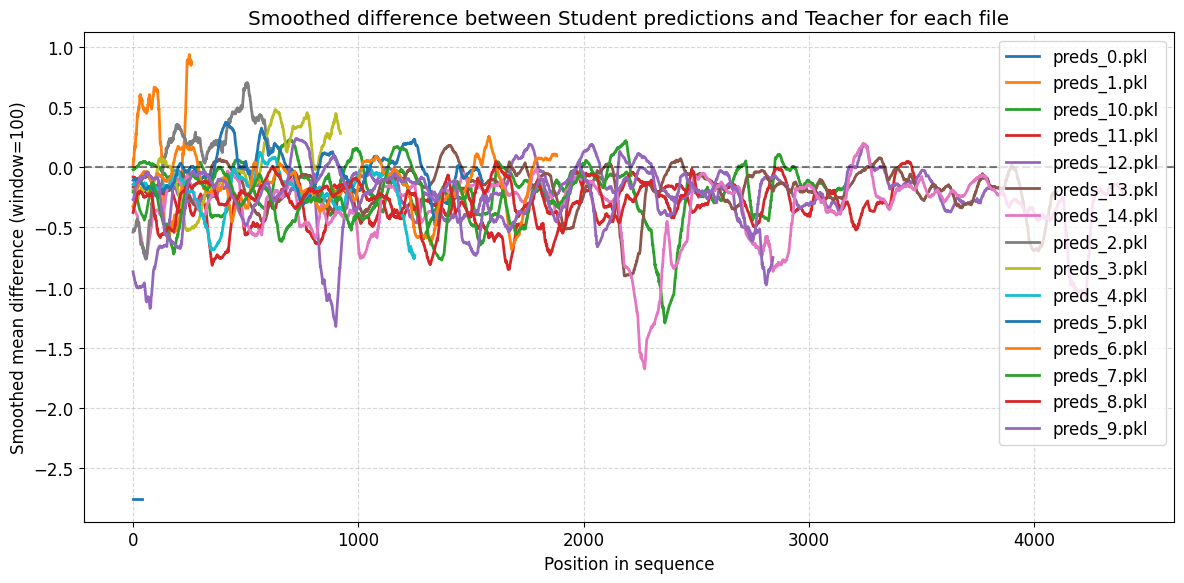

In [6]:
# --- Liste de tous les fichiers pickle ---
preds_pickle_files = sorted(glob.glob(os.path.join(run_dir, "preds_*.pkl")))
print(f"Found {len(preds_pickle_files)} pickle files.")

window_size = 100  # taille de la fenêtre de la moyenne glissante

plt.figure(figsize=(12, 6))

for path in preds_pickle_files:
    # --- Load pickle ---
    with open(path, "rb") as f:
        data = pickle.load(f)
    
    student_preds = data["student_pred_samples"]
    teacher_truth = data["teacher_true_samples"]
    
    # Flatten sequences
    student_preds_flat = [np.array(s).flatten() for s in student_preds]
    teacher_truth_flat = [np.array(t).flatten() for t in teacher_truth]
    
    # Compute difference for each sequence
    diffs = [s - t for s, t in zip(student_preds_flat, teacher_truth_flat)]
    
    # Compute mean difference across sequences in this file
    mean_diff = np.mean(np.stack(diffs), axis=0)
    
    # --- Apply moving average / rolling mean ---
    smoothed_diff = np.convolve(mean_diff, np.ones(window_size)/window_size, mode='valid')
    
    # Plot smoothed mean difference
    plt.plot(smoothed_diff, lw=2, label=os.path.basename(path))

plt.axhline(0, color='k', linestyle='--', alpha=0.5)  # zero line
plt.xlabel("Position in sequence")
plt.ylabel(f"Smoothed mean difference (window={window_size})")
plt.title("Smoothed difference between Student predictions and Teacher for each file")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

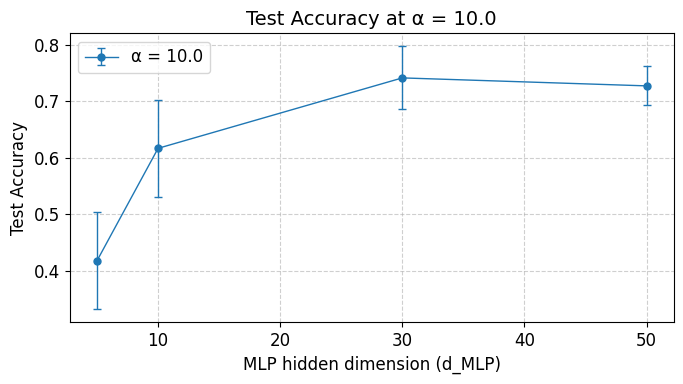

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Choisis l'alpha à analyser
alpha_fixed = max(df["alpha"])

# Filtrer le DataFrame pour cet alpha
subset_alpha = df[np.isclose(df["alpha"], alpha_fixed)].sort_values("MLP_dim")

# Tracer Test Accuracy vs MLP dimension
plt.figure(figsize=(7, 4))
plt.errorbar(
    subset_alpha["MLP_dim"],
    subset_alpha["acc_test_mean"],
    yerr=subset_alpha.get("acc_test_std", 0),
    marker='o',
    markersize=5,
    linewidth=1,
    capsize=3,
    label=f"α = {alpha_fixed}"
)

plt.xlabel("MLP hidden dimension (d_MLP)", fontsize=12)
plt.ylabel("Test Accuracy", fontsize=12)
plt.title(f"Test Accuracy at α = {alpha_fixed}", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=12)
plt.tight_layout()

# Sauvegarder le plot si besoin
plt.savefig(
    os.path.join(plot_path, f"test_accuracy_vs_dmlp_alpha{alpha_fixed}_run{run_id}.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Found 2 attention files and 2 preds files


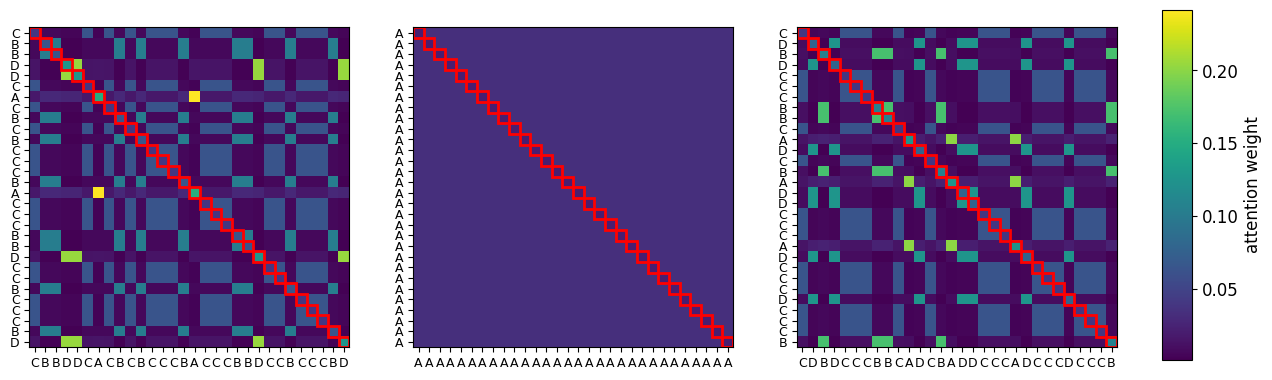

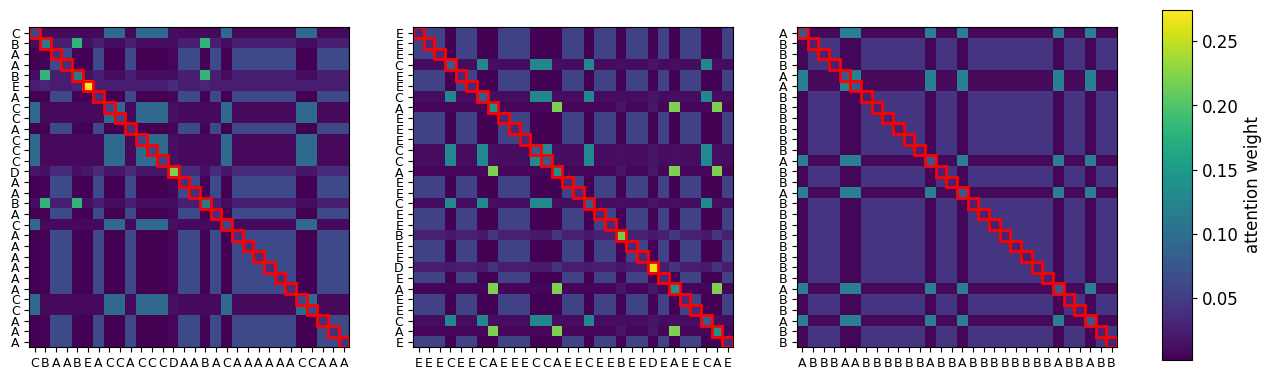

In [8]:
from operator import truth
import os
import glob
import pickle
import matplotlib.pyplot as plt
import numpy as np
import string

# run_id = "20251201_1537" # ok top pour le rapport 
run_id = "20251208_0815" # attention matrix

run_dir = f"../results/run_{run_id}/"
config_path = f"../results/run_{run_id}/config.csv"
base_path = f"../results/run_{run_id}/summary.csv"

plot_path = f"../results/run_{run_id}/plots/"
os.makedirs(plot_path, exist_ok=True)

# Load attention and sequences
attn_files = sorted(glob.glob(os.path.join(run_dir, "attn_*.pkl")))
preds_files = sorted(glob.glob(os.path.join(run_dir, "preds_*.pkl")))

print(f"Found {len(attn_files)} attention files and {len(preds_files)} preds files")

NUM_EXAMPLES = 3
RUN_IDX = 0
alphabet = list(string.ascii_uppercase)

for attn_path, preds_path in zip(attn_files, preds_files):

    # Load attention
    with open(attn_path, "rb") as f:
        attn_data = pickle.load(f)
    attn_all_runs = np.array(attn_data["attention_matrices"])

    # Load sequences
    with open(preds_path, "rb") as f:
        preds_data = pickle.load(f)
    seq_all_runs = preds_data["sequence_samples"]

    N_runs, N_samples, T, _ = attn_all_runs.shape

    # --- Select 3 examples ---
    attn_examples = attn_all_runs[RUN_IDX, :NUM_EXAMPLES, :, :]
    seq_examples = seq_all_runs[RUN_IDX][:NUM_EXAMPLES]

    # Determine global min/max for colorbar
    vmin = attn_examples.min()
    vmax = attn_examples.max()

    # --- Plot 3 matrices side by side ---
    fig, axes = plt.subplots(1, NUM_EXAMPLES, figsize=(5*NUM_EXAMPLES, 5))

    for idx in range(NUM_EXAMPLES):
        attn_matrix = attn_examples[idx]
        seq = seq_examples[idx]

        # Sequence → letters
        if seq.ndim == 2:
            token_seq = seq[:,0]
        elif seq.ndim == 1:
            token_seq = seq
        else:
            raise ValueError(f"Unexpected sequence shape: {seq.shape}")

        token_seq = token_seq[:T]
        token_labels = [alphabet[int(x) % len(alphabet)] for x in token_seq]

        ax = axes[idx]
        im = ax.imshow(attn_matrix, cmap="viridis", vmin=vmin, vmax=vmax)

        # Axis labels
        ax.set_xticks(np.arange(T))
        ax.set_xticklabels(token_labels, rotation=0, fontsize=9)
        ax.set_yticks(np.arange(T))
        ax.set_yticklabels(token_labels, fontsize=9)

        # Diagonal in red
        for i in range(T):
            rect = plt.Rectangle((i-0.5, i-0.5), 1, 1, linewidth=2, edgecolor='red', facecolor='none')
            ax.add_patch(rect)

        # ax.set_title(f"Sample {idx}", fontsize=14)

    # --- Add colorbar independently, outside axes ---
    fig.subplots_adjust(right=0.85)  # leave space on the right for colorbar
    cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
    fig.colorbar(im, cax=cbar_ax, label="attention weight")

    # fig.suptitle(f"Attention matrices — run {RUN_IDX}", fontsize=16)
    plt.savefig(
        os.path.join(plot_path, f"attention_matrices_run{RUN_IDX}_{os.path.basename(attn_path).replace('.pkl', '')}.png"),
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

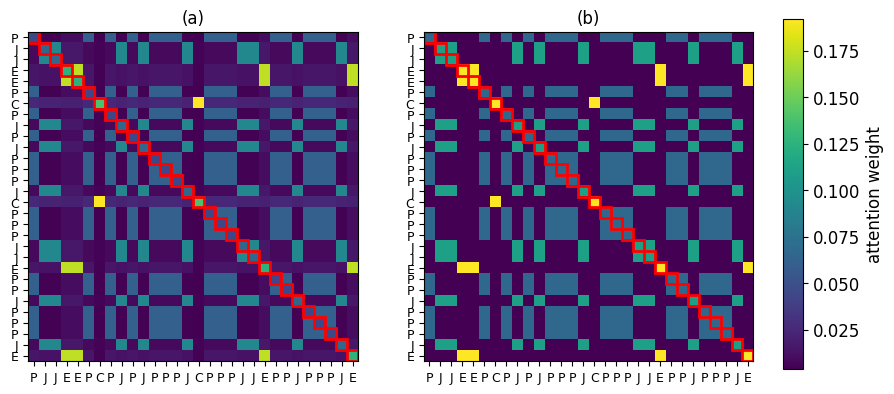

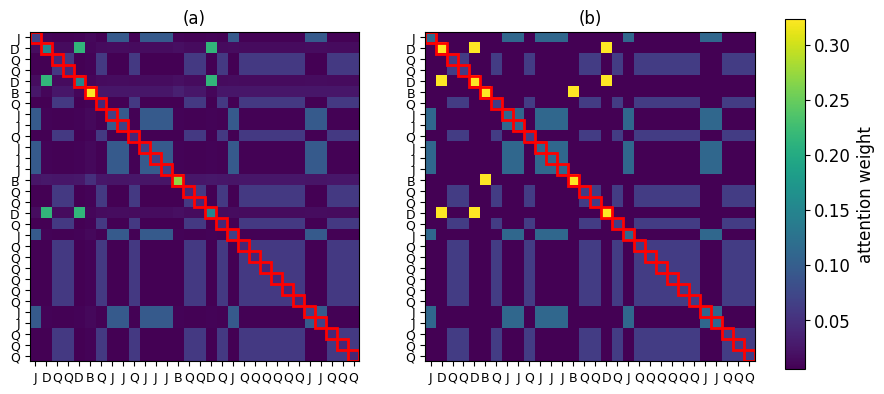

In [9]:
NUM_EXAMPLES = 1
RUN_IDX = 40
alphabet = list(string.ascii_uppercase)

for attn_path, preds_path in zip(attn_files, preds_files):

    # Load attention
    with open(attn_path, "rb") as f:
        attn_data = pickle.load(f)
    attn_all_runs = np.array(attn_data["attention_matrices"])

    # Load sequences
    with open(preds_path, "rb") as f:
        preds_data = pickle.load(f)
    seq_all_runs = preds_data["sequence_samples"]
    truth_all_runs = preds_data["teacher_true_samples"]

    N_runs, N_samples, T, _ = attn_all_runs.shape

    # --- Select examples ---
    attn_examples = attn_all_runs[RUN_IDX, :NUM_EXAMPLES, :, :]
    seq_examples = seq_all_runs[RUN_IDX][:NUM_EXAMPLES]
    truth_examples = truth_all_runs[RUN_IDX][:NUM_EXAMPLES]

    # --- Determine global min/max for colorbar ---
    vmin = attn_examples.min()
    vmax = attn_examples.max()

    # --- Plot predicted vs “soft true” attention ---
    fig, axes = plt.subplots(NUM_EXAMPLES, 2, figsize=(10, 5*NUM_EXAMPLES))

    for idx in range(NUM_EXAMPLES):
        attn_matrix = attn_examples[idx]
        seq_truth = truth_examples[idx]

        # Séquence → lettres
        if seq_truth.ndim == 2:
            token_seq = seq_truth[:,0]
        elif seq_truth.ndim == 1:
            token_seq = seq_truth
        else:
            raise ValueError(f"Unexpected sequence shape: {seq_truth.shape}")

        token_seq = token_seq[:T]
        token_labels = [alphabet[int(x) % len(alphabet)] for x in token_seq]

        # --- Construire la vraie matrice d’attention probabiliste ---
        truth_matrix = np.zeros((T, T))
        for i in range(T):
            # positions avec le même token sauf la diagonale
            match_positions = np.where((token_seq == token_seq[i]))[0]
            if match_positions.size > 0:
                truth_matrix[i, match_positions] = 1.0 / match_positions.size
            # si aucune correspondance, reste 0

        # --- Affichage prédiction vs vraie attention ---
        for j, mat in enumerate([attn_matrix, truth_matrix]):
            ax = axes[idx, j] if NUM_EXAMPLES > 1 else axes[j]
            im = ax.imshow(mat, cmap="viridis", vmin=vmin, vmax=vmax)

            ax.set_xticks(np.arange(T))
            ax.set_xticklabels(token_labels, rotation=0, fontsize=9)
            ax.set_yticks(np.arange(T))
            ax.set_yticklabels(token_labels, fontsize=9)

            # Diagonal en rouge
            for k in range(T):
                rect = plt.Rectangle((k-0.5, k-0.5), 1, 1, linewidth=2, edgecolor='red', facecolor='none')
                ax.add_patch(rect)

            ax.set_title("(a)" if j==0 else "(b)", fontsize=12)

    # --- Add colorbar ---
    fig.subplots_adjust(right=0.85)
    cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7])
    fig.colorbar(im, cax=cbar_ax, label="attention weight")

    plt.savefig(
        os.path.join(plot_path, f"attention_vs_truth_run{RUN_IDX}_{os.path.basename(attn_path).replace('.pkl', '')}.png"),
        dpi=500,
        bbox_inches="tight"
    )

    plt.show()